Département de génie électrique - Polytechnique Montréal

Analyse des signaux - ELE2700

TP5 version 3.0: A2025

---
Numéro d'équipe: #102

Noms, prénoms et matricules:

- Machraoui, Simon : 2487824

- Beaumier, Édouard : 2087482


>⚠ **Attention:**
>
> Avant de commencer à modifier le notebook, assurez-vous de le sauvegarder dans votre *Google Drive* personnel.
>

#$\color{#18a2f2}{\textbf{TP5 - Échantillonnage}}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
from scipy.signal import resample

## $\color{#03fc9d}{\textbf{Exercice 1, évalué en classe (8pt/20):}}$
# <font color='green'>Introduction à l'échantillonnage </font>

L'échantillonnage est un processus fondamental en analyse des signaux, permettant de convertir un signal continu en un signal discret, ce qui est essentiel pour le traitement numérique des signaux dans des applications comme la commande en robotique.



$\color{orange}{\text{a) [code]}}$ Dans le contexte d'une articulation robotique, il est essentiel de surveiller la position. Considérons que cette position est représentée par la somme d'un signal sinusoïdal de 90 Hz et d'un signal sinusoïdal de 180hz, simulant les mouvements répétitifs de l'articulation. Générer ce signal avec une fréquence d'échantillonnage de 1800 Hz et le tracer à l'aide de `matplotlib` et de sa commande `stem`. $\color{red}{\textbf{(1pt/20)}}$

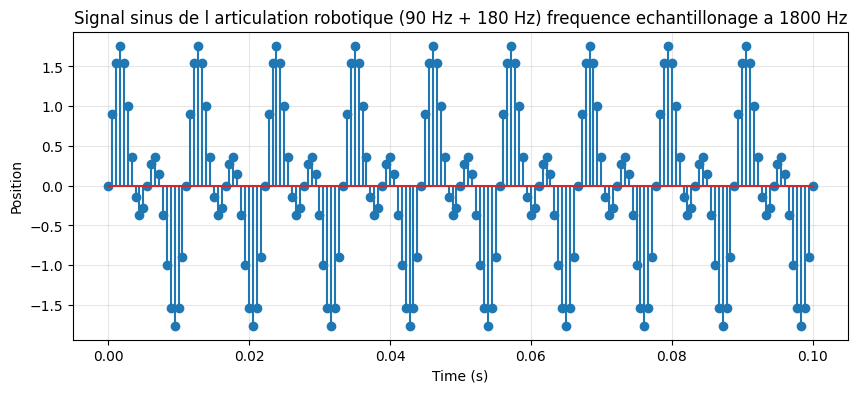

In [26]:
def generate_time_vec(t1, t2, fs , endpoint = True):
    num_samples = int(fs * (t2 - t1)) + (1 if endpoint else 0)
    return np.linspace(t1, t2, num_samples, endpoint)

t1 = 0
t2 = 0.1

# Compléter le code ici pour a)
t_a = generate_time_vec(t1, t2, fs=1800) 
signal_a = np.sin(2 * np.pi * 90 * t_a)+ np.sin(2 * np.pi * 180 * t_a)

plt.figure(figsize=(10, 4))
plt.stem(t_a, signal_a)
plt.xlabel('Time (s)')
plt.ylabel('Position')
plt.title('Signal sinus de l articulation robotique (90 Hz + 180 Hz) frequence echantillonage a 1800 Hz')
plt.grid(True, alpha=0.3)
plt.show()

$\color{orange}{\text{b) [code]}}$ Pour optimiser l'espace mémoire, nous envisageons de réduire la fréquence d'échantillonnage. Échantillonner le signal généré en a) à une fréquence de 360 Hz et tracer le résultat. $\color{red}{\textbf{(1pt/20)}}$

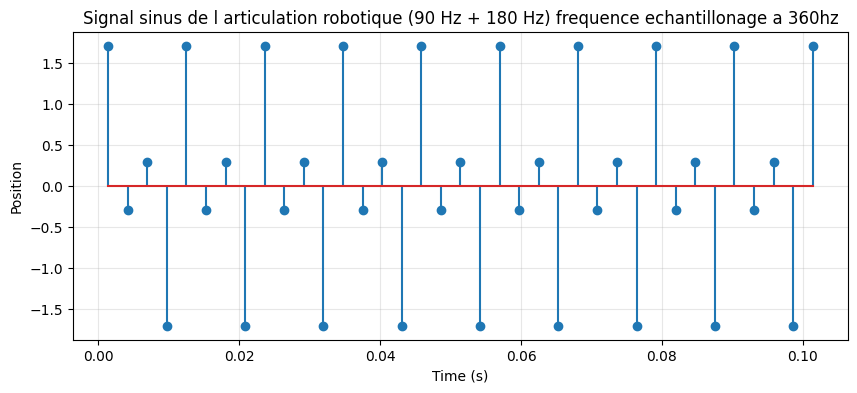

In [28]:
# Décalage de T/4 pour éviter d'avoir échantillons nuls
t1 = 1/180/4
t2 = 0.1+t1

# Compléter le code ici pour b)
t_b = generate_time_vec(t1, t2, fs=360)
signal_b = np.sin(2 * np.pi * 90 * t_b)+ np.sin(2 * np.pi * 180 * t_b)

plt.figure(figsize=(10, 4))
plt.stem(t_b, signal_b)
plt.xlabel('Time (s)')
plt.ylabel('Position')
plt.title('Signal sinus de l articulation robotique (90 Hz + 180 Hz) frequence echantillonage a 360hz') 
plt.grid(True, alpha=0.3)
plt.show()

# <font color='green'>Impact de la fréquence d'échantillonnage </font>

Le théorème de Shannon-Nyquist énonce que pour qu'un signal à bande limitée soit entièrement représenté par ses échantillons, il doit être échantillonné à une fréquence d'au moins deux fois sa fréquence maximale. La figure suivante représente le cas du sous-échantillonnage, où $f_\text{s} < 2f_{\max}$.

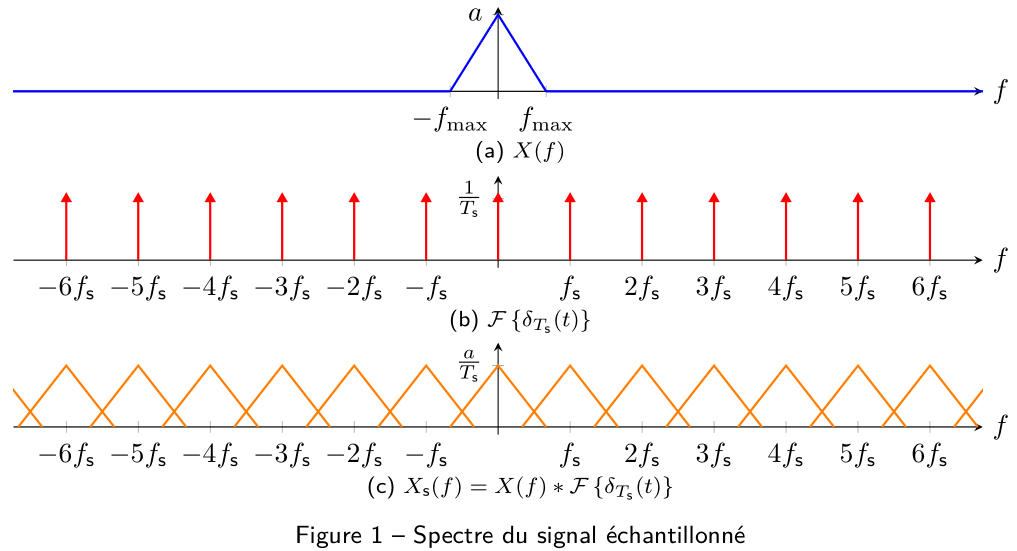


$\color{orange}{\text{c) [code]}}$ Pour étudier davantage l'impact de la fréquence d'échantillonnage, échantillonner le signal de a) à des fréquences plus basses (300 Hz, 225 Hz, 150 Hz). Tracer les signaux échantillonnés pour chaque fréquence. $\color{red}{\textbf{(1pt/20)}}$

> **Note** : Utiliser `t1=0` et `t2=1`.

In [ ]:
# Écrire votre code ici pour c)
t1 = 0
t2 = 0.1

# Fréquences du signal (inchangées)
f1 = 90
f2 = 180
fmax = f2

# Fréquence d'échantillonnage trop faible : en dessous de 2*fmax
fs_sous = 200  # < 2 * 180 = 360 Hz  --> sous-échantillonnage !

# Échantillonnage du signal à 200 Hz
t_sous = generate_time_vec(t1, t2, fs_sous)
x_sous = np.sin(2 * np.pi * f1 * t_sous) + np.sin(2 * np.pi * f2 * t_sous)

# --- Tracé des signaux ---
plt.figure(figsize=(10,5))
plt.plot(t, signal_a, label="Signal original (continu)", linewidth=1)
plt.stem(t_sous, x_sous, linefmt='r-', markerfmt='ro', basefmt='k', label="Échantillons (fs=200 Hz)")
plt.title("Impact du sous-échantillonnage : fs < 2*fmax (aliasing)")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()



$\color{orange}{\text{d) [code]}}$ Utiliser la transformée de Fourier pour afficher le spectre des signaux échantillonnés. $\color{red}{\textbf{(1pt/20)}}$



> **Note** : Utiliser l'argument `endpoint = False` de la fonction `generate_time_vec` pour un meilleur affichage.

In [ ]:
# Écrire votre code ici pour d)

$\color{orange}{\text{e) [Analyse écrite]}}$ Discuter de l'effet du sous-échantillonnage sur le spectre du signal. Utiliser la théorème de Nyquist-Shannon pour déterminer quelles fréquences sont bien représentées. $\color{red}{\textbf{(2pt/20)}}$



**Écrire votre réponse ici pour e).**

$\color{orange}{\text{ f) [Démarche manuscrite ou } \LaTeX \text{]}}$ Considérer le signal suivant:

$$ x(t) = \mathrm{e}^{-100t} , \quad t \geq 0. $$

Afin de numériser ce signal, vous décidez de filter le signal à l'aide d'un filtre passe-bas idéal de gain unitaire ayant une fréquence de coupure $f_\mathrm{max}$ et ensuite de l'échantillonner à une fréquence d'échantillonnage $f_\mathrm{s}$. Déterminer la valeurs de $f_\mathrm{max}$ permettant de conserver 97.5% de l'énergie totale du signal, ainsi que la valeur minimale de $f_\mathrm{s}$ nécessaire pour échantillonner le signal filtré. $\color{red}{\textbf{(2pt/20)}}$



---
---
Insérez votre démarche ici.

---
---

## $\color{#03fc9d}{\textbf{Exercice 2, devoir (4pt/20):}}$

# <font color='green'>Théorème de reconstruction de Shannon </font>

La capacité de reconstruire un signal continu à partir de ses échantillons est fondamentale en traitement du signal. Selon le théorème de reconstruction de Shannon, un signal continu peut être parfaitement reconstruit à partir de ses échantillons s'il est limité en bande et échantillonné à une fréquence au moins deux fois supérieure à sa fréquence maximale (fréquence de Nyquist). Une reconstruction précise permet de garantir que l'information d'origine est préservée et peut être utilisée de manière fiable dans diverses applications.

$\color{orange}{\text{a) [Code]}}$ Dans le contexte d'un robot, considérer que les mouvements d'une articulation robotique sont échantillonnés. Utiliser une fonction de reconstruction pour recréer ce signal continu à partir des échantillons d'un signal sinusoïdal de 75 Hz échantillonné à une fréquence de 200 Hz. Afficher le signal original, le signal échantillonné à 200 Hz et le signal reconstruit. $\color{red}{\textbf{(2pt/20)}}$


In [ ]:
def sinc_interpolation(t, t_sampled, x_sampled):
    T = t_sampled[1] - t_sampled[0]  # Intervalle ech. = 1/fs
    reconstructed = np.zeros_like(t)

    for n, tn in enumerate(t_sampled):
        reconstructed += x_sampled[n] * np.sinc((t - tn) / T)

    return reconstructed

In [ ]:
# Écrire votre code ici pour a)

$\color{orange}{\text{b) [Analyse écrite]}}$ En se basant sur le mouvement de l'articulation robotique, comparer le signal reconstruit avec le signal original. Est-il possible de récupérer fidèlement le signal original à partir des échantillons et de garantir un contrôle précis du robot? $\color{red}{\textbf{(1.5pt/20)}}$


**Écrire votre réponse ici pour b).**

$\color{orange}{\text{c) [Analyse écrite]}}$ Donner un désavantage de ce type de reconstruction du signal continu. Justifier dûment. $\color{red}{\textbf{(0.5pt/20)}}$

**Écrire votre réponse ici pour c).**

## $\color{#03fc9d}{\textbf{Exercice 3, devoir (8pt/20):}}$
# <font color='green'>Chevauchement et filtres anti-chevauchement </font>

Dans le domaine de la robotique, obtenir des mesures propres est crucial pour le bon fonctionnement des commandes. Cependant, le chevauchement (*aliasing*) est un phénomène indésirable qui peut se produire lors du sous-échantillonnage d'un signal. Un filtre anti-chevauchement est souvent utilisé pour éviter ce phénomène, garantissant que les capteurs ne fournissent que les informations pertinentes pour le mouvement du robot.

$\color{orange}{\text{a) [Photo dans case texte]}}$ Considérer le signal suivant:
$$x(t) = \sum_{n\in\mathbb{Z}}\tilde{x}( t-nT),$$
où,
$$\tilde{x}( t)= \begin{cases}
1-\frac{8}{T}t, &\text{ si } 0 \leq t < \frac{T}{4}\\
-1, &\text{ si } \frac{T}{4} \leq t < \frac{T}{2} \\
-5+\frac{8}{T}t, &\text{ si } \frac{T}{2} \leq t < \frac{3T}{4}\\
1, &\text{ si } \frac{3T}{4} \leq t < T \\
0, &\text{ sinon,}
\end{cases}$$
où $T$ est égale à 10 millisecondes. Déterminer analytiquement les fréquences observées si le signal est échantillonné à 450 Hz. $\color{red}{\textbf{(2pt/20)}}$



---

---


*Insérer une photo de vos démarches pour (a) (papier, $\LaTeX$ ou tablette)*.



---

---

$\color{orange}{\text{b) [Code]}}$ Générer numériquement le signal $x(t)$ et afficher son spectre. Échantillonner à 450 Hz pour valider vos résultats. $\color{red}{\textbf{(1pt/20)}}$

In [ ]:
# Écrire votre code ici pour b)

$\color{orange}{\text{c) [Code]}}$ Considérons qu'un capteur du robot mesure le  défini en a) avec une fréquence d'échantillonnage de 1200 Hz. Cependant, il y a également des interférences et un signal sinusoïdal parasite est présent à 750 Hz due à la vibration du système. Générer un signal représentant ces mesures, puis l'échantillonner à 1200 Hz. Afficher le spectre du signal échantillonné.

Le signal peut être échantillonné à une nouvelle fréquence d'échantillonnage en utilisant la fonction `np.interp`, qui effectue une interpolation linéaire. Cela permet de reconstruire le signal à des instants de temps spécifiques.
$\color{red}{\textbf{(1pt/20)}}$

> **Note** : Utiliser l'argument `endpoint = False` de la fonction `generate_time_vec` pour un meilleur affichage.

In [ ]:
# Écrire votre code ici pour c)

$\color{orange}{\text{d) [Analyse écrite]}}$ Sur la base du signal échantillonné, quelles fréquences observez-vous? Pourquoi ces fréquences sont-elles présentes, et comment le taux d'échantillonnage influence-t-il ce que vous observez? $\color{red}{\textbf{(1pt/20)}}$

**Écrire votre réponse ici pour d).**

$\color{orange}{\text{e) [Code]}}$ Pour garantir que ce signal soit propre avant de l'utiliser pour la commande du robot, utiliser un filtre anti-chevauchement d'ordre 5 pour éliminer les fréquences supérieures à 510 Hz. Afficher le signal filtré dans le domaine fréquentiel. $\color{red}{\textbf{(1pt/20)}}$


La fonction `butter` de la bibliothèque `scipy` est utilisée pour créer un filtre passe-bas. Elle génère deux séries de coefficients (`b` et `a`) qui définissent le comportement du filtre. Ensuite, la fonction `filtfilt` applique ce filtre au signal, en atténuant les fréquences supérieures à la fréquence de coupure définie.

In [ ]:
## Exemple d'utilisation
#from scipy.signal import butter, filtfilt

## Génération des coefficients du filtre
# b, a = butter(ordre_du_filtre, fréquence_de_coupure_relative)

## Application du filtre au signal
#signal_filtre = filtfilt(b, a, signal)


Après le filtrage, le signal peut être échantillonné à une nouvelle fréquence d'échantillonnage en utilisant la fonction `np.interp`.

In [ ]:
# signal_echantillonne_filtre = np.interp(nouveaux_points_temporels, temps_originaux, signal_filtre)

In [ ]:
# Écrire votre code ici pour e)

$\color{orange}{\text{f) [Analyse écrite]}}$ Quel est l'effet du filtre anti-chevauchement sur le signal échantillonné? Pourquoi est-il essentiel, dans une application robotique, d'utiliser un tel filtre avant de prendre des décisions basées sur l'entrée échantillonnée? $\color{red}{\textbf{(2pt/20)}}$

**Écrire votre réponse ici pour f).**

## $\color{#03fc9d}{\textbf{Précisions pour la remise:}}$

* Pour chaque exercice, répondre en ajoutant des cases de code ou de texte en dessous de la question.

* Remettez sur moodle un fichier `.ipynb` ainsi qu'une version `pdf` contenant seulement les exercices 2 et 3) avec toutes les librairies et importations nécessaires pour que le code roule.

* Indiquer noms, matricules et numéro d'équipe au début du `notebook`.